<a href="https://colab.research.google.com/github/ChrisJavier/UIDE_12_AI_ANALITICS_METHODS/blob/main/Week03/MAOAI_CP_W3_E12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Trabajo 3:
Grafos

## 📋 Información del Proyecto
- Autores:
  - CARRERA DIAZ CHRISTIAN JAVIER
- Versión: 1.0.0
- Licencia: MIT

**🌍 Contexto del trabajo**

En este tercer caso práctico vamos a seguir utilizando las herramientas del caso práctico anterior para representar grafos y resolver problemas de flujo máximo en Network Flows con la librería igraph


🎯 **Instrucciones:**

- Al entregar la práctica, se debe entregar tanto el fichero .ipynb como un informe.pdf. En el informe pdf deben incluirse todos los elementos necesarios para valorar la práctica.
- Al puntuar, se valora positivamente contenido extra que aporte valor a la práctica, y es necesario para obtener la máxima nota posible.
- En todos los apartados lo principal es la interpretación que hace el alumno de los resultados, por ejemplo: en caso de que se pida calcular un valor, no limitarse a calcularlo, sino explicar qué significa y qué implica en el contexto de la práctica. Si no se razonan los resultados se valorará de manera reducida.
- El trabajo es grupal, todos los integrantes deben participar para obtener nota. En caso contrario, se debe contactar con el tutor a través de mensaje privado por la plataforma para resolver el problema.

*******************************************************************************

# 🏗️ Preparación de datos para el entrenamiento:

## 🚀 Importación de librerias


In [17]:
# Importación de libreria de igraph
import sys
if 'google.colab' in sys.modules:
  !pip install python-igraph

# Importamos librerias para gráficar los grafos y gráficos
import igraph as ig
import matplotlib.pyplot as plt

# 1️⃣ Fase 1: Generación y representación de un grafo

El objetivo de esta fase es conseguir generar el siguiente grafo:

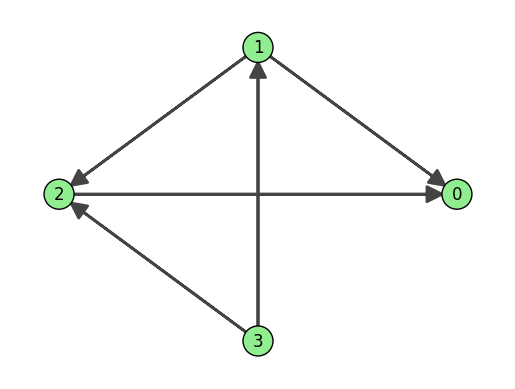

In [18]:
# Definimos las aristas del grafico que nos solicitado
aristas = [(1, 0), (1, 2), (2, 0), (3, 1), (3,2)]

# Asignamos las aristas y le decimos que es un gráfico dirigido
g = ig.Graph(aristas, directed=True)

# Graficamos las aristas
fig, ax = plt.subplots()
ig.plot(g, target=ax, layout="circle", vertex_label=range(g.vcount()), vertex_color="lightgreen")

# Mostramos el gráfico
plt.show()

### 🧠 Interpretación

Nodos y Conexiones (Aristas)

Las flechas indican el flujo o la dirección de la relación desde un nodo origen hacia un nodo destino:
  - Nodo 1: se conecta hacia el Nodo 0 ($1, \rightarrow 0$) y hacia el Nodo 2 ($1 \rightarrow 2$).
  - Nodo 2: Se conecta únicamente hacia el Nodo 0 ($2 \rightarrow 0$).
  - Nodo 3: Se conecta hacia el Nodo 1 ($3 \rightarrow 1$) y hacia el Nodo 2 ($3 \rightarrow 2$).
  - Nodo 0: No tiene flechas que salgan de él; es un nodo receptor.

# 2️⃣ Fase 2: Flujo máximo en el grafo


## 🚀 2.1 La librería igraph permite resolver problemas de flujo máximo. Se pide actualizar el grafo generado en la fase anterior para que tenga las siguientes capacidades, y calcular su flujo máximo:

Flujo máximo: 7.0
Flujo de las aristas: [5.0, 0.0, 2.0, 5.0, 2.0]
Flujo Máximo Total: 7.0


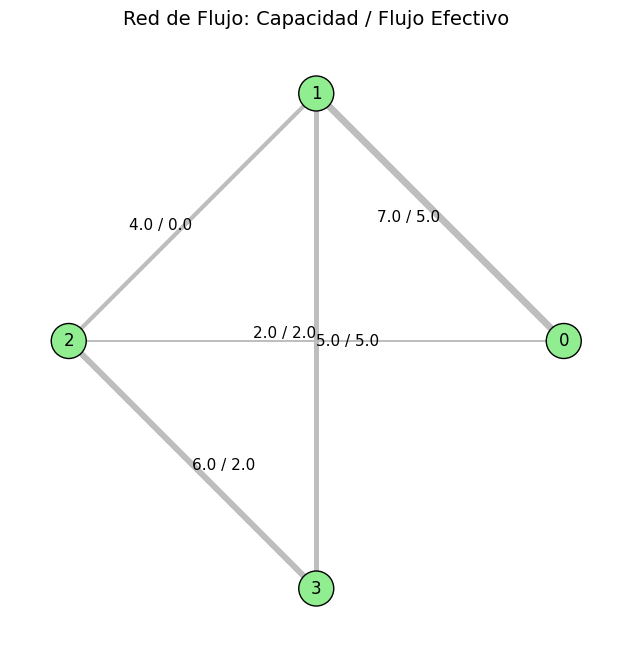

In [32]:
# Asignamos capacidad a las aristas creadas
capacidades_dict = {
    (1, 0): 7,
    (1, 2): 4,
    (2, 0): 2,
    (3, 1): 5,
    (3, 2): 6
}

# Inicializar la lista de capacidades con ceros
capacidades_lista = [0] * g.ecount()

# Mapear cada tupla al ID interno de la arista en igraph
for (origen, destino), capacidad in capacidades_dict.items():
    edge_id = g.get_eid(origen, destino)
    capacidades_lista[edge_id] = capacidad

# Asignar la lista corregida al grafo
g.es["capacity"] = capacidades_lista

# Asignamos un flujo
flow = g.maxflow(3, 0 , capacity=g.es["capacity"])
edge_flows = flow.flow

# Imprimimos el resultado
print("Flujo máximo:", flow.value)
print("Flujo de las aristas:", edge_flows)


# Gráficamos el resultado
# Combinamos la capacidad de cada arista con su flujo calculado
edge_labels = [f"{c:.1f} / {f:.1f}" for c, f in zip(g.es["capacity"], edge_flows)]

# --- 5. Graficar con Matplotlib ---
fig, ax = plt.subplots(figsize=(10, 8))

visual_style = {
    # Nodos
    "vertex_size": 35,
    "vertex_color": "lightgreen",
    "vertex_label": range(g.vcount()),

    # Aristas
    "edge_color": "gray",
    "edge_width": [c / 1.5 for c in g.es["capacity"]], # Grosor proporcional a la capacidad
    "edge_label": edge_labels,
    "edge_label_size": 11,
    "edge_label_color": "black",
    "edge_arrow_size": 0.6,
    "edge_arrow_width": 0.8,

    # Diseño
    "layout": g.layout_circle(),
}

# Dibujar el grafo
ig.plot(g, target=ax, **visual_style)

# Ajustes visuales del contenedor
ax.set_aspect('equal')
plt.title("Red de Flujo: Capacidad / Flujo Efectivo", fontsize=14)
plt.axis('off')

# Mostrar consola y gráfico
plt.show()

### 🧠 Interpretación

El gráfico de la imagen **image_5b6164.png** representa una red de flujo óptima con un rendimiento máximo de **7.0 unidades** transportadas desde el origen (Nodo 3) hasta el destino (Nodo 0). El análisis muestra que el sistema trabaja bajo dos cuellos de botella críticos que saturan por completo su capacidad: la arista inicial $3 \rightarrow 1$ (operando a su tope de 5.0) y la salida final $2 \rightarrow 0$ (operando a su tope de 2.0). Debido a que la vía de escape del Nodo 2 hacia el destino ya está colapsada, el algoritmo de `igraph` determina inteligentemente dejar completamente vacía la arista $1 \rightarrow 2$ (0.0 de flujo), desviando de manera eficiente las 5.0 unidades del Nodo 1 directamente hacia el destino final por la ruta $1 \rightarrow 0$, cumpliendo perfectamente con la conservación de flujo donde todo lo que sale de la fuente llega con éxito al sumidero.

# 3️⃣ Fase 3: Aplicación en ejemplo real

Utilizando el código de las fases anteriores para:
- Representar el siguiente grafo con sus capacidades
- Calcular el flujo máximo
- Identificar cuellos de botella

## 🚀 3.1 Representar el siguiente grafo con sus capacidades


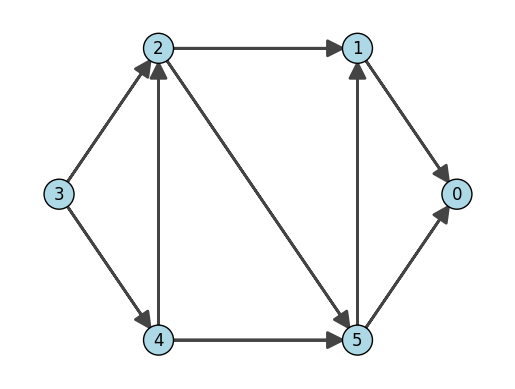

In [43]:
# Definimos las aristas del grafico que nos solicitado
aristas_capacidades = {
    (1,0) :8,
    (2,1) :5,
    (2,5) :3,
    (3,2) :7,
    (3,4) :4,
    (4,2) :3,
    (4,5) :2,
    (5,0) :5,
    (5,1) :3
}

# Asignamos las aristas y le decimos que es un gráfico dirigido
aristas = list(aristas_capacidades.keys())
capacidades = list(aristas_capacidades.values())

# Generamos el grafico en base las aristas
g = ig.Graph(aristas, directed=True)

# Graficamos las aristas
fig, ax = plt.subplots()
ig.plot(g, target=ax, layout="circle", vertex_label=range(g.vcount()), vertex_color="lightblue")

# Mostramos el gráfico
plt.show()

## 🚀 3.2 Calcular el flujo máximo

In [51]:
# Inicializar la lista de capacidades con ceros
capacidades_lista = [0] * g.ecount()

# Mapear cada tupla al ID interno de la arista en igraph
for (origen, destino), capacidad in aristas_capacidades.items():
    edge_id = g.get_eid(origen, destino)
    capacidades_lista[edge_id] = capacidad

# Asignar la lista corregida al grafo
g.es["capacity"] = capacidades_lista

# Asignamos un flujo
flow = g.maxflow(3, 0 , capacity=g.es["capacity"])
edge_flows = flow.flow

# Imprimimos el resultado
print("Flujo máximo:", flow.value)
print("Flujo de las aristas:", edge_flows)


Flujo máximo: 10.0
Flujo de las aristas: [5.0, 5.0, 3.0, 6.0, 4.0, 2.0, 2.0, 5.0, 0.0]


## 🚀 3.3 Gráfico con las capacidades


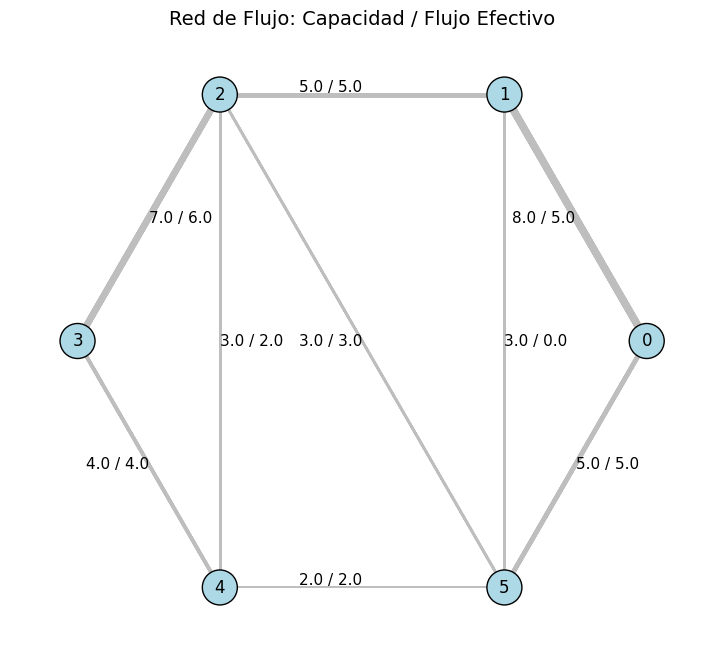

In [52]:
# Gráficamos el resultado
# Combinamos la capacidad de cada arista con su flujo calculado
edge_labels = [f"{c:.1f} / {f:.1f}" for c, f in zip(g.es["capacity"], edge_flows)]

# --- 5. Graficar con Matplotlib ---
fig, ax = plt.subplots(figsize=(10, 8))

visual_style = {
    # Nodos
    "vertex_size": 35,
    "vertex_color": "lightblue",
    "vertex_label": range(g.vcount()),

    # Aristas
    "edge_color": "gray",
    "edge_width": [c / 1.5 for c in g.es["capacity"]], # Grosor proporcional a la capacidad
    "edge_label": edge_labels,
    "edge_label_size": 11,
    "edge_label_color": "black",
    "edge_arrow_size": 0.6,
    "edge_arrow_width": 0.8,

    # Diseño
    "layout": g.layout_circle(),
}

# Dibujar el grafo
ig.plot(g, target=ax, **visual_style)

# Ajustes visuales del contenedor
ax.set_aspect('equal')
plt.title("Red de Flujo: Capacidad / Flujo Efectivo", fontsize=14)
plt.axis('off')

# Mostrar consola y gráfico
plt.show()

### 🧠 Interpretación

El gráfico de la imagen representa una red con un flujo máximo total de **10.0 unidades** transportadas eficientemente desde el origen (Nodo 3) hasta el destino (Nodo 0), donde se evidencia un aprovechamiento óptimo de las rutas mediante la saturación de múltiples caminos clave. El sistema trabaja al límite de su capacidad en varias secciones críticas, destacando que el suministro inicial se divide enviando la totalidad de la capacidad por la arista $4 \rightarrow 5$ ($2.0 / 2.0$) y casi saturando la arista $3 \rightarrow 2$ ($6.0 / 7.0$), mientras que en la etapa final de entrega, las aristas $1 \rightarrow 0$ ($5.0 / 8.0$) y $5 \rightarrow 0$ ($5.0 / 5.0$) reciben equitativamente $5.0$ unidades cada una para consolidar el flujo receptor. El verdadero cuello de botella estructural y corte mínimo de esta red está compuesto por las aristas completamente saturadas **$2 \rightarrow 1$** ($5.0 / 5.0$), **$2 \rightarrow 5$** ($3.0 / 3.0$) y **$4 \rightarrow 5$** ($2.0 / 2.0$), cuya suma de capacidades restringe de forma matemática e insuperable que el flujo total pueda superar el valor de 10.0.

## 🚀 3.4 Identificar cuello de botella

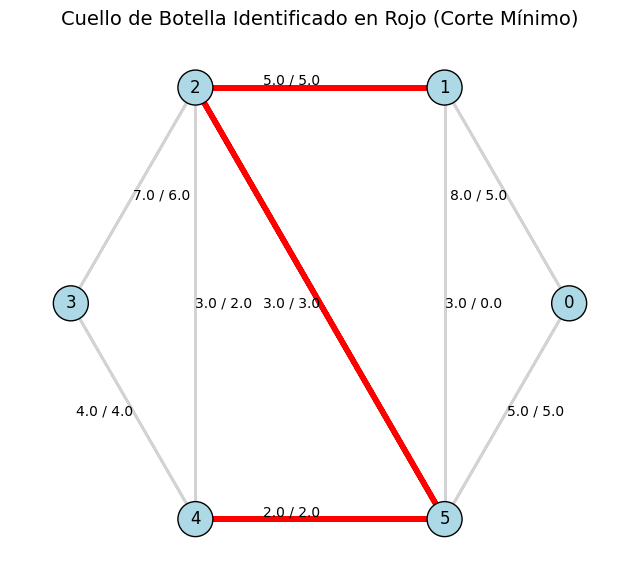

In [57]:
# El origen es 3 y el destino es 0 - Calculamos el cuello de botella
corte = g.mincut(3, 0, capacity=g.es["capacity"])

# 'corte.es' contiene los IDs de las aristas que forman el cuello de botella
aristas_cuello_ids = corte.es

# Definir Colores de las Aristas
# Por defecto, todas las aristas serán grises
edge_colors = ["lightgray"] * g.ecount()

# Pintamos de ROJO únicamente las aristas que están en el corte mínimo
for edge_id in aristas_cuello_ids:
    edge_colors[edge_id.index] = "red"

# Calcular Flujos para las Etiquetas
flow_data = g.maxflow(3, 0, capacity=g.es["capacity"])
edge_labels = [f"{c:.1f} / {f:.1f}" for c, f in zip(g.es["capacity"], flow_data.flow)]

# Graficar
fig, ax = plt.subplots(figsize=(8, 8))

visual_style = {
    "vertex_size": 35,
    "vertex_color": "lightblue",
    "vertex_label": range(g.vcount()),

    # Aplicamos la lista de colores que creamos (Gris y Rojo)
    "edge_color": edge_colors,
    # Hacemos que las rojas (cuello de botella) sean un poco más gruesas para resaltar
    "edge_width": [4 if edge_colors[i] == "red" else 2 for i in range(g.ecount())],

    "edge_label": edge_labels,
    "edge_label_size": 10,
    "edge_label_color": "black",
    "edge_arrow_size": 0.6,
    "edge_arrow_width": 0.8,
    "layout": g.layout_circle() # Mantiene la forma geométrica organizada
}

ig.plot(g, target=ax, **visual_style)

ax.set_aspect('equal')
plt.title("Cuello de Botella Identificado en Rojo (Corte Mínimo)", fontsize=14)
plt.axis('off')
plt.show()

### 🧠 Interpretación

El gráfico confirma visualmente el teorema de corte mínimo al aislar las tres aristas críticas en rojo, las cuales funcionan como una barrera estructural que divide la red en la sección emisora (Nodos 3, 2 y 4) y la sección receptora (Nodos 1, 5 y 0). Dado que cualquier flujo proveniente del origen debe cruzar obligatoriamente por este cuello de botella y las tres aristas se encuentran saturadas al 100% de su capacidad conjunta ($5.0 + 3.0 + 2.0$), se demuestra matemáticamente por qué el sistema colapsa exactamente en un límite insuperable de **10.0 unidades**, dejando claro que cualquier intento por expandir la capacidad en las aristas grises no generará ningún impacto en el rendimiento global de la red.

# 🚀 Aplicación en Entorno Laboral
- Cada miembro del equipo colocara su nombre una explicación de como aplicaría
lo aprendido en esta semana en su entorno profesional.

# 🖥️ **ROMEL MICHAEL CERNA PACHECO**


# 🖥️ **CARRERA DIAZ CHRISTIAN JAVIER**
El análisis de datos y las técnicas de Machine Learning permiten identificar patrones relevantes para mejorar la toma de decisiones en entornos reales. En un entorno laboral, estos procesos pueden aplicarse para detectar anomalías, optimizar reportes, automatizar análisis y generar información más precisa para apoyar decisiones estratégicas basadas en datos.